In [1]:
import numpy as np
import matplotlib.pyplot as plt


import plopp as pp

# Load data as Scipp DataArray

In [2]:
import os
import sys

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

import scipp as sc
import mcstastox as mx

file_path = parent + "/runs/LET_vanad"


with mx.Read(file_path) as mcstas_data:
    scipp_data_group = mcstas_data.export_scipp(
        source_name="SourceMantid",
        sample_name="iso_samp",
    )
display(scipp_data_group)

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 25886}),
    positions: Variable({'pixel_id': 30056}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

# Group by pixel_id to fill in the missing pixels

In [3]:
events_binned = scipp_data_group["events"]
display(events_binned)
pos = scipp_data_group["positions"]
events = events_binned.group(sc.arange(pos.dim, 0, pos.size))
display(events)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:25886, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 30053, 30054]
* position                  vector3              [m]  (pixel_id)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.3436, 1.98529, 22.4005), (2.30641, 1.98529, 22.3674)]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 59921),
          data=float64[counts],
          coords={'t':float64[s]})

<scipp.DataArray>
Dimensions: Sizes[pixel_id:30056, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 30054, 30055]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 59921),
          data=float64[counts],
          coords={'t':float64[s]})

In [4]:
# events_binned.transform_coords("Qx",graph={"Qx":lambda t, position: t*position.fields.x}).bin(Qx=100, dim=('pixel_id',))

# Flatten the binning by detector pixel_id

In [5]:
events_binned = scipp_data_group["events"]
# assigen pixel_id and position to binned events
events_binned.bins.coords["pixel_id"] = sc.bins_like(
    events_binned.data, events_binned.coords.pop("pixel_id")
)
events_binned.bins.coords["detector_positions"] = sc.bins_like(
    events_binned.data, events_binned.coords.pop("position")
)
# unpack binned event data
events = events_binned.bins.concat().value.copy()
# copy other coordinates
events.coords["sample_position"] = events_binned.coords.pop("sample_position")
events.coords["source_position"] = events_binned.coords.pop("source_position")
# McStas provides absolute time, not time of flight, rename
events.coords["tof"] = events.coords.pop("t")

print(events)

<scipp.DataArray>
Dimensions: Sizes[events:59921, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.30641, 1.98529, 22.3674)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 1, ..., 30054, 30054]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (events)  [0.0345534, 0.0345478, ..., 0.0345157, 0.0346881]
Data:
                            float64         [counts]  (events)  [1.12736e-13, 1.03091e-29, ..., 0.0353246, 0.00972432]




# Add monitor position as coordinate

In [6]:
with mx.Read(file_path) as mcstas_data:
    monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="Monitor6"
    )
events.coords["monitor_position"] = sc.vector(value=monitor_position, unit="m")

print(events)

<scipp.DataArray>
Dimensions: Sizes[events:59921, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.30641, 1.98529, 22.3674)]
* monitor_position          vector3              [m]  ()  (0, 0, 23.505)
* pixel_id                    int64  [dimensionless]  (events)  [0, 1, ..., 30054, 30054]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (events)  [0.0345534, 0.0345478, ..., 0.0345157, 0.0346881]
Data:
                            float64         [counts]  (events)  [1.12736e-13, 1.03091e-29, ..., 0.0353246, 0.00972432]




# Get monitor counts and TOA centroid, add as coordinates

In [7]:
import mcstasscript as ms

from reduction.dgs_reduction import _calc_pulse_centroid

mcstas_data = ms.load_data(file_path)

monitor_data = ms.name_search("Monitor6", mcstas_data)
events.coords["monitor_counts"] = sc.scalar(
    value=monitor_data.Intensity.sum(), unit="counts"
)

toa_centroids = _calc_pulse_centroid(monitor_data)
# --------- look up table for time on monitor ----------------
look_up_tab = sc.DataArray(data=toa_centroids, coords={"tof": toa_centroids})
tof_to_centroid = sc.lookup(look_up_tab, mode="previous")
events = events.transform_coords(time_on_monitor=tof_to_centroid)
# ------------------------------------------------------------
print(events)

<scipp.DataArray>
Dimensions: Sizes[events:59921, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.30641, 1.98529, 22.3674)]
* monitor_counts            float64         [counts]  ()  41770.6
* monitor_position          vector3              [m]  ()  (0, 0, 23.505)
* pixel_id                    int64  [dimensionless]  (events)  [0, 1, ..., 30054, 30054]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
* time_on_monitor           float64              [s]  (events)  [0.0280169, 0.0280169, ..., 0.0280169, 0.0280169]
  tof                       float64              [s]  (events)  [0.0345534, 0.0345478, ..., 0.0345157, 0.0346881]
Data:
                            float64         [counts]  (events)  [1.12736e-13, 1.03091e-29, ..., 0.0353246, 0.00972432]




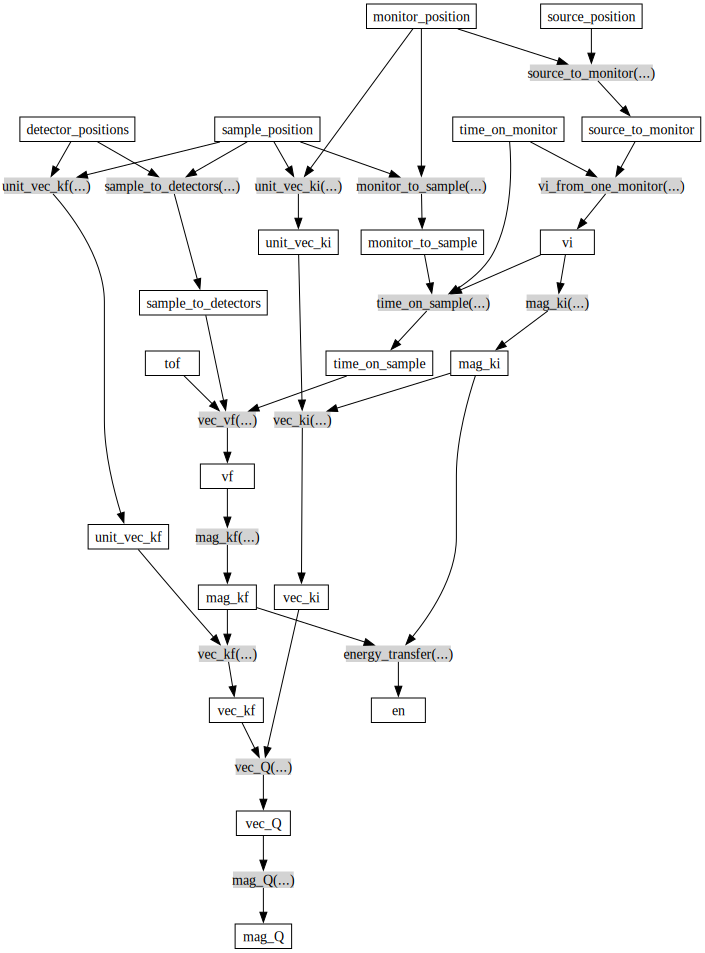

In [8]:
from scippneutron.conversion.graph.beamline import beamline
from reduction.dgs_reduction import dgs_reduction

# qens_graph = {**beamline(scatter=True), **dgs_reduction}
events = events.transform_coords(["vec_Q", "mag_Q", "en"], graph=dgs_reduction)
sc.show_graph(dgs_reduction)

In [11]:
sc.constants.m_n

<scipp.Variable> ()    float64             [kg]  1.67493e-27

In [10]:
print(events)

<scipp.DataArray>
Dimensions: Sizes[events:59921, ]
Coordinates:
  detector_positions        vector3              [m]  (events)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.30641, 1.98529, 22.3674), (2.30641, 1.98529, 22.3674)]
* en                        float64            [meV]  (events)  [-0.0648848, -0.0738023, ..., -0.12497, 0.138534]
* mag_Q                     float64           [1/Å]  (events)  [1.08686, 1.07457, ..., 2.4441, 2.40066]
  mag_kf                    float64           [1/Å]  (events)  [1.34418, 1.34578, ..., 1.35492, 1.30715]
  mag_ki                    float64           [1/Å]  (events)  [1.33248, 1.33248, ..., 1.33248, 1.33248]
* monitor_counts            float64         [counts]  ()  41770.6
  monitor_position          vector3              [m]  ()  (0, 0, 23.505)
  monitor_to_sample         float64              [m]  ()  1.495
* pixel_id                    int64  [dimensionless]  (events)  [0, 1, ..., 30054, 30054]
  sample_position       

In [9]:
# create (qx, qy, qz, en)
# Note: Need to use copy() to allow for binning later
events.bins.coords["qx"] = events.bins.coords["Q"].fields.x.copy()
events.bins.coords["qy"] = events.bins.coords["Q"].fields.y.copy()
events.bins.coords["qz"] = events.bins.coords["Q"].fields.z.copy()


events_binned

AttributeError: 'NoneType' object has no attribute 'coords'

# Calculate minimum and maximum kf

In [ ]:
Lm = events_binned.coords["Lm"]


def _calc_mag_kf_from_ef(ef):
    hbar = sc.constants.hbar
    m_n = sc.constants.neutron_mass
    kf = sc.sqrt(2 * m_n * ef) / hbar
    return kf.to(unit="1/angstrom")


monitor = ms.name_search("Monitor6", data)
tom_centroid = _calc_pulse_centroid(monitor)
vi = Lm / tom_centroid

ei = (0.5 * sc.constants.m_n * vi**2).to(unit="meV")

unit_ki = sc.vector([0, 0, 1])
mag_ki = ((sc.constants.neutron_mass * vi) / sc.constants.hbar).to(unit="1/angstrom")

ki = unit_ki * mag_ki


prop_ei = 0.8
max_ef = (1 + prop_ei) * ei
min_ef = (1 - prop_ei) * ei

min_kf = _calc_mag_kf_from_ef(min_ef)
max_kf = _calc_mag_kf_from_ef(max_ef)

print(f"min_kf: {min_kf}, max_kf: {max_kf}")

# Access and calculate detector trajectory endpoints

In [ ]:
sample_position = events_binned.coords["sample_position"]
pixel_vec = scipp_data_group["positions"] - sample_position
pixel_vec = pixel_vec / sc.norm(pixel_vec)

Q_max = ki.to(unit="1/Å") - (pixel_vec * max_kf)
Q_min = ki.to(unit="1/Å") - (pixel_vec * min_kf)

kf_max = sc.broadcast(max_kf, dims=Q_max.dims, shape=Q_max.shape)
kf_min = sc.broadcast(min_kf, dims=Q_min.dims, shape=Q_min.shape)

kf_min

# Calculate detector solid angles dOmega (detector counts/monitor counts)

In [ ]:
scale_factor = (
    events_binned.data.sum()
    / events_binned.coords["monitor_counts"]
    * (4 * sc.constants.pi)
)
dOmega = (
    events_binned.bins.sum().data
    / events_binned.coords["monitor_counts"]
    * (4 * sc.constants.pi)
)
events_binned.coords["dOmega"] = dOmega

# Generate 4D grid for histogramming

In [ ]:
bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-0.1, 0.1),
    qz=(-1, 3.0, 0.1),
    en=(-0.2, 0.2),
)

# convert energy to kf

In [ ]:
hbar = sc.constants.hbar
m_n = sc.constants.neutron_mass

kf_array = (
    (sc.sqrt(2 * m_n * (ei[0] - bins["en"])) / hbar)
    .to(unit="1/Å")
    .rename_dims({"en": "mag_kf"})
)
bins["mag_kf"] = kf_array[~sc.isnan(kf_array)]
bins["mag_kf"] = sc.sort(bins["mag_kf"], key="mag_kf")

edges = {key: bins[key] for key in ("qx", "qy", "qz", "mag_kf")}
display(edges)

# Calculate normalization factor per pixel

In [ ]:
hbar = sc.constants.hbar
m_n = sc.constants.neutron_mass


def _calc_en_from_kf_endpoints(kf_in, kf_out):
    en = hbar**2 / m_n * 0.5 * ((kf_in**2 - kf_out**2) * sc.Unit("1/Å^2"))
    return sc.abs(en).to(unit="meV")

In [ ]:
from voxel_traversal_4d import voxel_traversal_4d

# create norm_array
dims = list(edges.keys())
shape = [var.sizes[dim] - 1 for dim, var in edges.items()]

norm_arr = sc.zeros(
    dims=dims,
    shape=shape,
    unit=sc.Unit("meV^"),
)

edges_arr = [edge.values for edge in edges.values()]

# loop over all pixels

for pixel in range(Q_max.sizes["pixel_id"]):
    # calculate intersections
    start = np.concatenate(
        [Q_min["pixel_id", pixel].values[0], kf_min["pixel_id", pixel].values]
    )
    end = np.concatenate(
        [Q_max["pixel_id", pixel].values[0], kf_max["pixel_id", pixel].values]
    )
    for idx, p_in, p_out in voxel_traversal_4d(start, end, edges_arr):
        i, j, k, l = idx
        *_, kf_in = p_in
        *_, kf_out = p_out
        dE_i = _calc_en_from_kf_endpoints(kf_in, kf_out)

        # solid angle
        dOmega_i = dOmega["pixel_id", pixel]

        # sum
        norm_arr["qx", i]["qy", j]["qz", k]["mag_kf", l] += dE_i * dOmega_i

# Histogram data

In [ ]:
%matplotlib widget

data_hist = sc.bin(events_binned.data, **edges).hist()
display(data_hist)
pp.plot(
    data_hist.squeeze().transpose(),
    coords=["qx", "qz"],
    grid=True,
    cmap="turbo",
)

# Data divided by normalization factor

In [ ]:
data_hist.squeeze()

In [ ]:
norm_arr

In [ ]:
# norm_factor = events.bins.concat().value.copy()
# norm_factor.data = sc.bins_like(events, events.coords["dOmega"]).bins.concat().value

# norm_hist = sc.bin(norm_factor, **edges).hist()

pp.plot(
    (data_hist.squeeze().transpose()) / norm_arr.squeeze(),
    coords=["qx", "qz"],
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e5,
)